In [ ]:
# data
import pandas as pd
import numpy as np
import os
from pathlib import Path
parent = Path.cwd().parent

# visualization
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno


# styling
%matplotlib inline
sns.set_style('darkgrid')
mpl.rcParams['font.size'] = 14
mpl.rcParams['figure.facecolor'] = '#00000000'
mpl.rcParams['font.size'] = 14
mpl.rcParams['figure.facecolor'] = '#00000000'


# from wordcloud import WordCloud

import warningsb
warnings.filterwarnings("ignore")

#### Explore Data

In [ ]:
#Read data
row_data_rpath = os.path.join(Path.cwd().parent,"data/raw/credit_risk_dataset.csv")
print(f'loading {row_data_rpath}')
data =  pd.read_csv(row_data_rpath) 



# Print sample
data.sample(3).reset_index(drop=True)

loading /home/josalkb/Documentos/ml_projects/mlops/credit_risk/credit_risk2605/data/raw/credit_risk_dataset.csv


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,26,58000,MORTGAGE,1.0,MEDICAL,D,25000,13.55,1,0.43,Y,4
1,23,23520,RENT,8.0,MEDICAL,A,4200,NaN,0,0.18,N,3
2,24,87000,MORTGAGE,6.0,PERSONAL,B,6000,10.65,0,0.07,N,4


In [ ]:
# Exploere data structure
def struc (df, nsample=3):
    '''Explores data structure by showing data types, number of unique values and a sample of the data.'''
    notnull_ptj = (df.notnull().sum()/len(df)).apply(lambda x: f'{x:.2%}')
    notnull_df = df.notnull().sum().apply(lambda x: f'{x:,}')       
    out_df =  pd.concat([df.dtypes, notnull_df, notnull_ptj , df.nunique(), df.sample(nsample).reset_index(drop=True).T], axis=1)
    out_df.columns = ['dtype', 'notnull', 'notnull_pct',     'nunique'] + [f'sample_{i}' for i in range(1,nsample+1)]
    return out_df
print(struc(data, nsample=1))

,dtype,notnull,notnull_pct,nunique,sample_1,sample_2,sample_3
person_age,int64,"32,581",100.00%,58,22,24,24
person_income,int64,"32,581",100.00%,4295,70000,85000,134300
person_home_ownership,str,"32,581",100.00%,4,MORTGAGE,RENT,MORTGAGE
person_emp_length,float64,"31,686",97.25%,36,5.0,0.0,2.0
loan_intent,str,"32,581",100.00%,6,DEBTCONSOLIDATION,EDUCATION,MEDICAL
loan_grade,str,"32,581",100.00%,7,C,A,E
loan_amnt,int64,"32,581",100.00%,753,15000,16000,12000
loan_int_rate,float64,"29,465",90.44%,348,13.92,6.91,16.45
loan_status,int64,"32,581",100.00%,2,0,0,1
loan_percent_income,float64,"32,581",100.00%,77,0.21,0.19,0.08


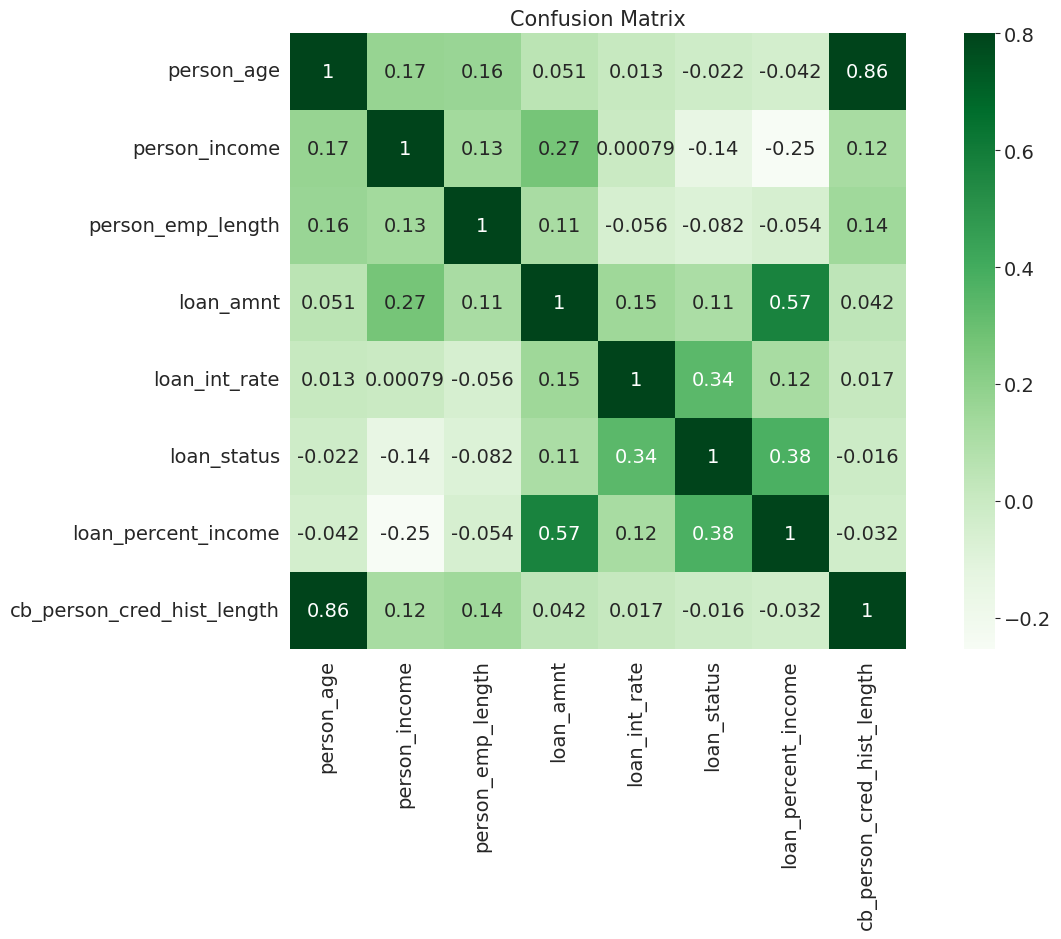

In [69]:
# Inspect correlations of not string ftrs
fig, ax = plt.subplots() 
fig.set_size_inches(15,8)
sns.heatmap(data.select_dtypes(include='number').corr(), vmax =.8, square = True, annot = True,cmap='Greens' )
plt.title('Confusion Matrix',fontsize=15);

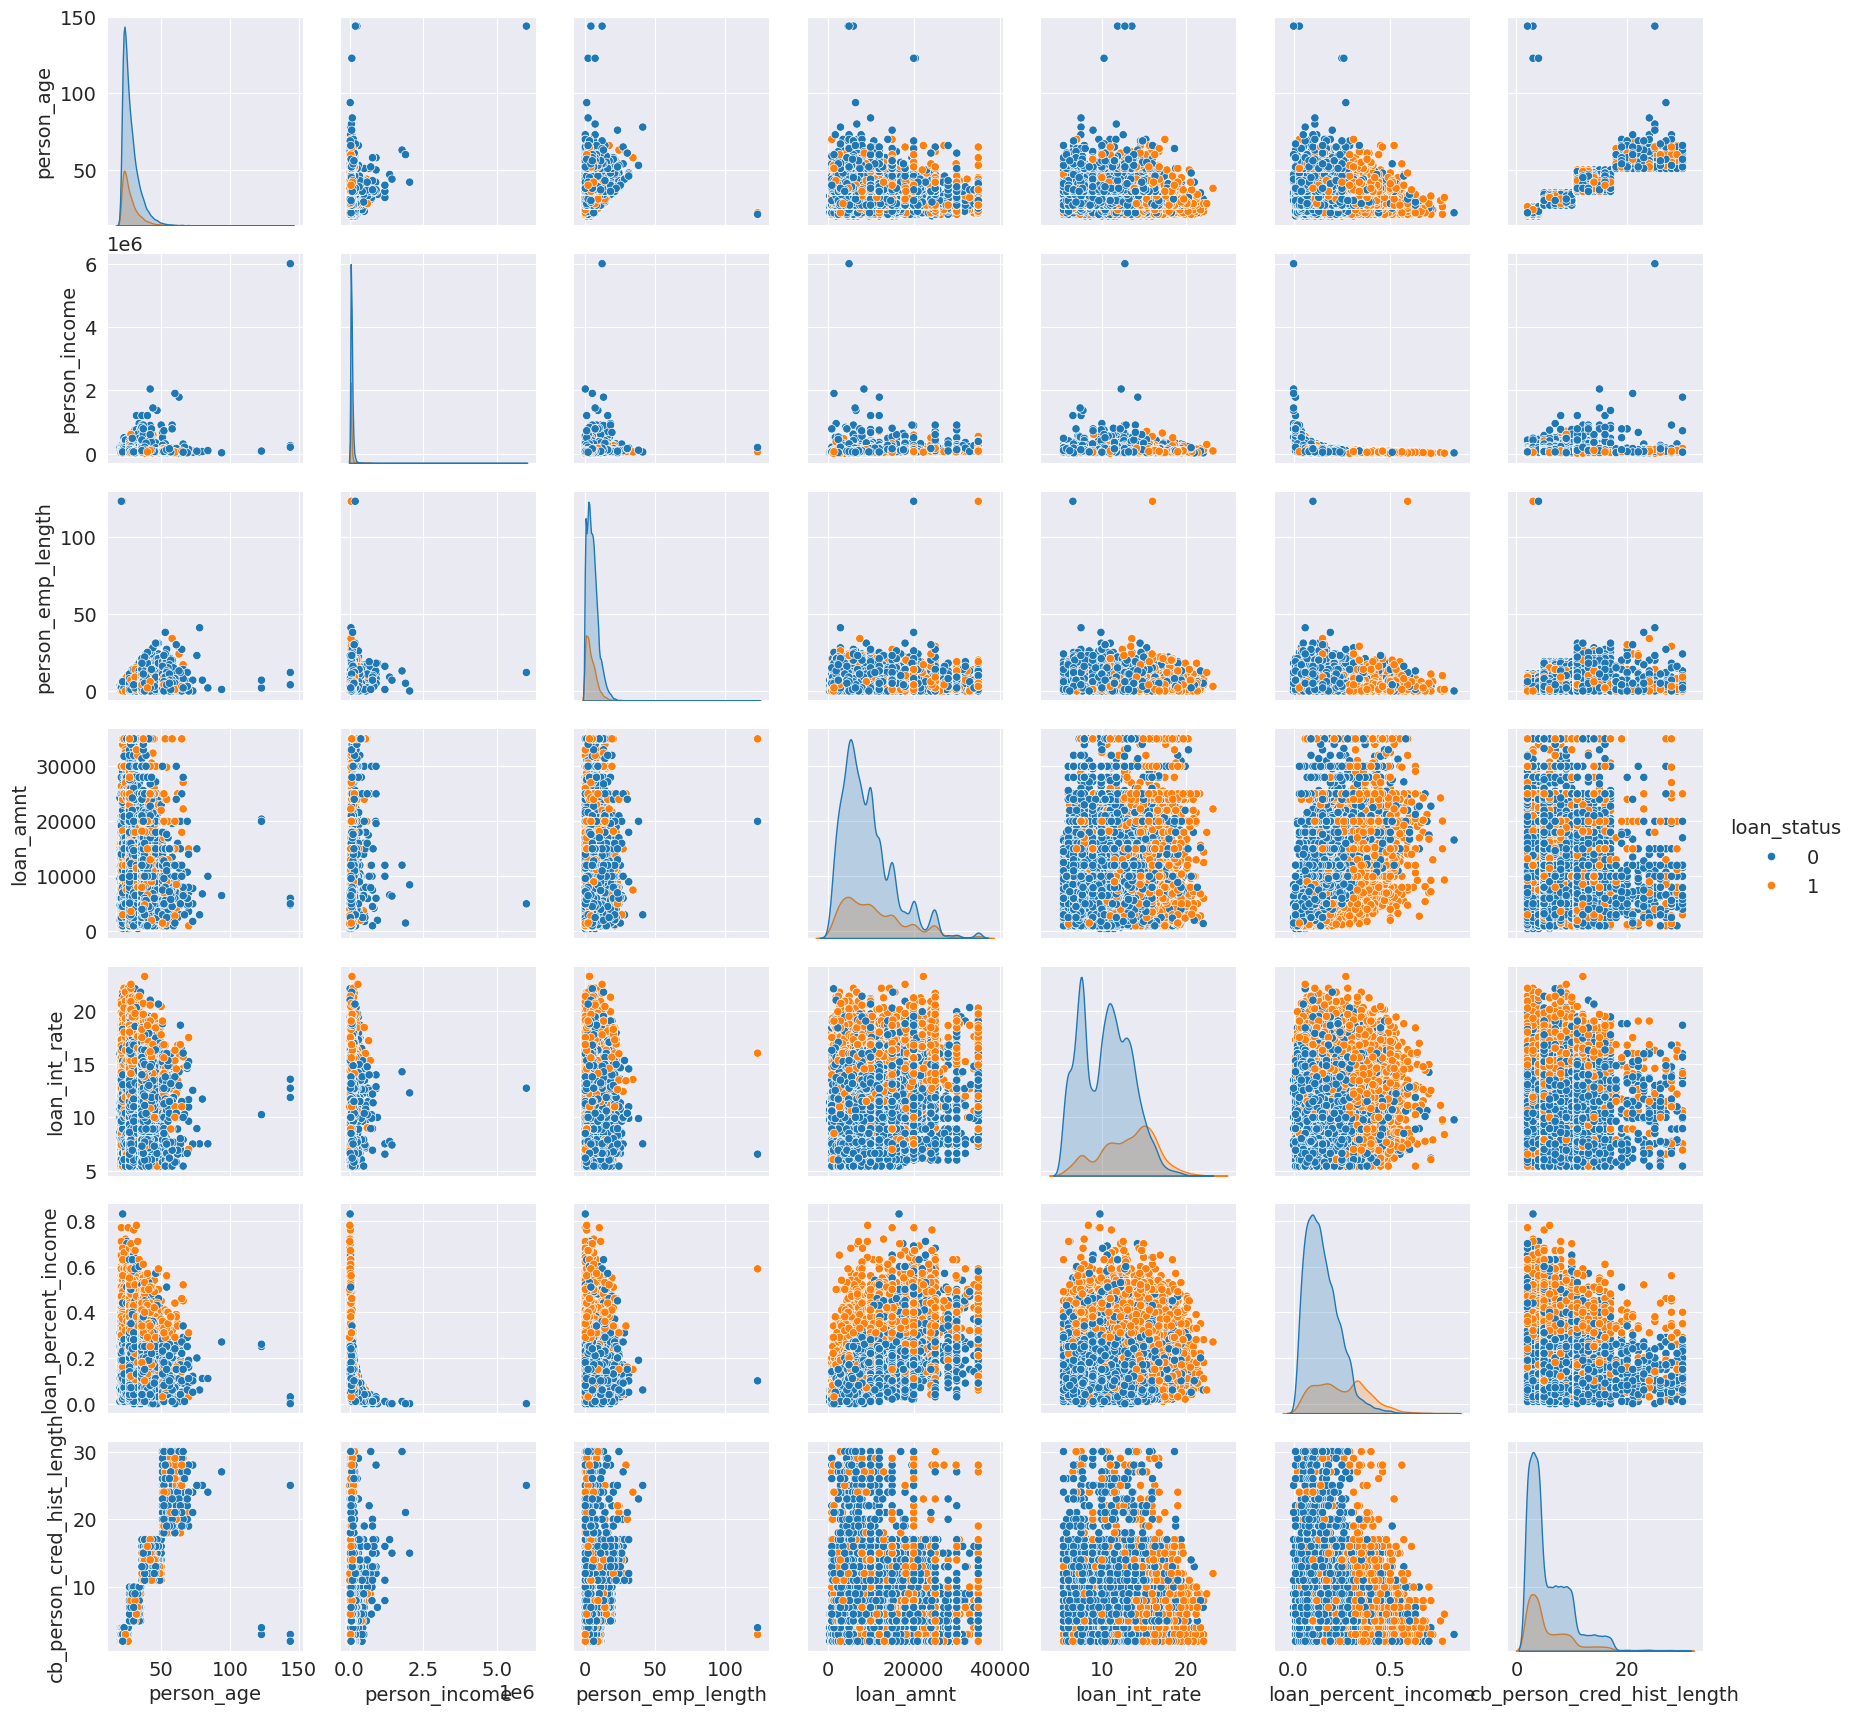

In [ ]:
# Explore paired distributions vs target.
# int rate and loan percent income seem to have different dist on defaulter vs non defaulter.
# person age,income and emp_length seem to have outliers.

sns.pairplot(data,hue="loan_status")

      person_income  count
0             60000   1046
1             30000    847
2             50000    778
3             40000    658
4             45000    590
...             ...    ...
4260        1440000      1
4285        1782000      1
4293        1900000      1
4080        2039784      1
4266        6000000      1

[4295 rows x 2 columns]


<Axes: xlabel='person_income'>

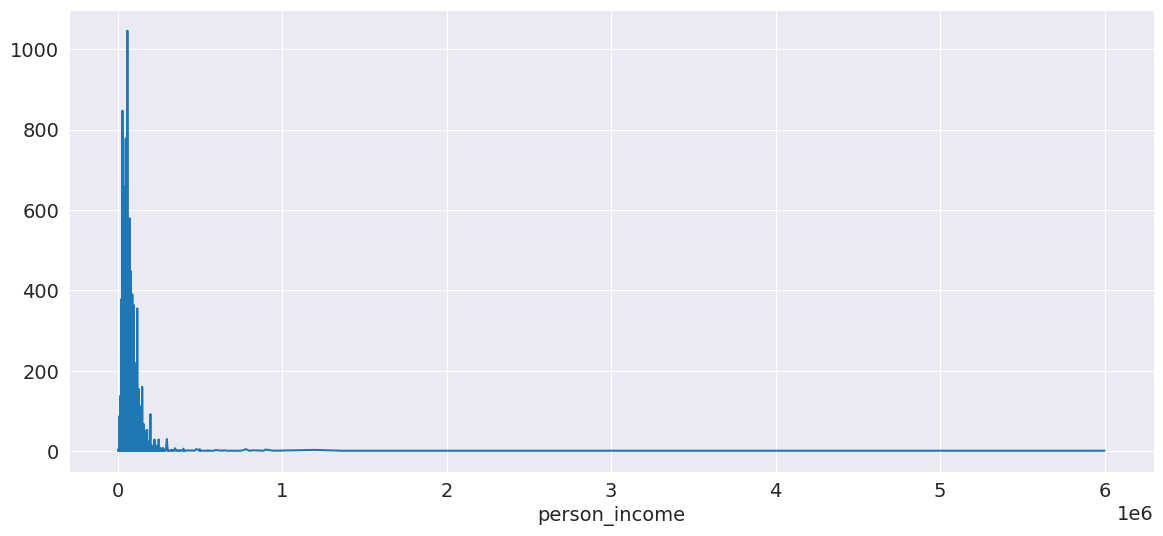

In [ ]:
# Explore distribution. Is very skewed but seems ok. Max val  is 60 Million income
print(data['person_income'].value_counts().reset_index().sort_values(by=['count','person_income'], ascending=[False,True]))
data['person_income'].value_counts().sort_index().plot(figsize=(14,6))

    person_age  count
0           23   3889
1           22   3633
2           24   3549
3           25   3037
4           26   2477
5           27   2138
6           28   1854
7           29   1687
8           30   1316
9           21   1229
10          31   1142
11          32    964
12          33    856
13          34    709
14          35    620
15          36    548
16          37    478
17          38    373
18          39    302
19          40    271
20          41    241
21          42    188
22          43    164
23          44    141
24          45    108
25          46     94
26          47     94
27          48     75
28          50     52
29          49     49
30          51     39
31          52     36
32          53     30
33          54     24
34          55     20
35          58     19
36          20     15
39          56     15
37          57     15
38          60     15
42          61      9
40          65      9
41          66      9
43          62      7
44        

<Axes: xlabel='person_age'>

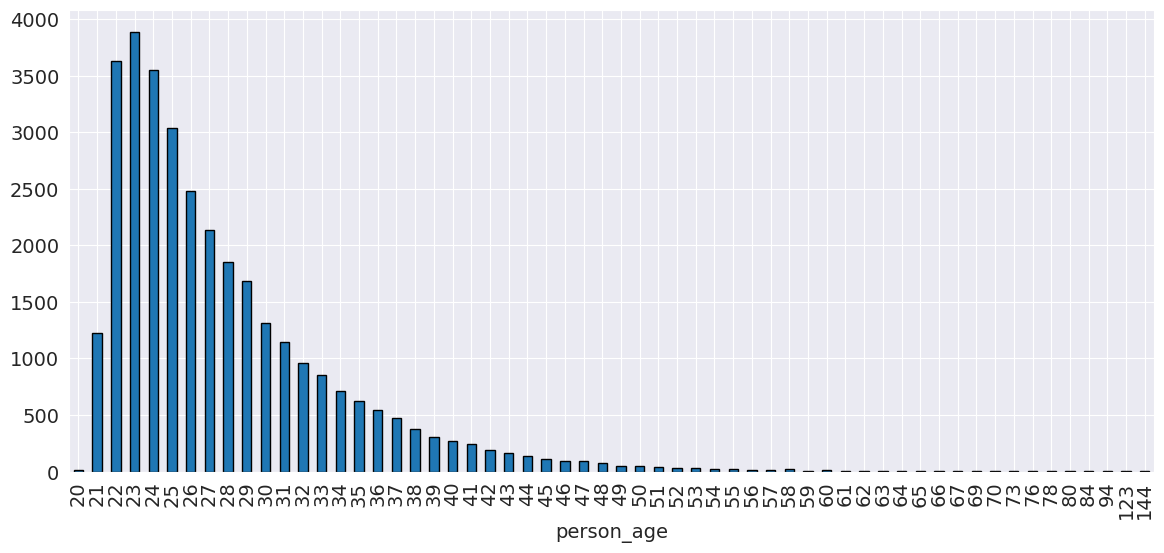

In [137]:
# Explore age distribution. Seem to be 2 extreme values
print(data['person_age'].value_counts().reset_index().sort_values(by=['count','person_age'], ascending=[False,True]))
print(data.loc[data['person_age']>=90,:])
data['person_age'].value_counts().sort_index().plot.bar(edgecolor='black', figsize=(14,6))

    person_emp_length  count
0                 0.0   3708
1                 2.0   3469
2                 3.0   3133
3                 5.0   2715
4                 1.0   2644
5                 4.0   2571
6                 6.0   2394
7                 7.0   1971
8                 8.0   1534
9                 9.0   1227
10               11.0    663
11               10.0    631
12               12.0    519
13               13.0    380
14               14.0    306
15               15.0    213
16               16.0    152
17               17.0    115
18               18.0     96
19               19.0     61
20               20.0     36
21               21.0     33
22               22.0     18
23               23.0     10
25               25.0      8
24               24.0      8
26               27.0      5
28               31.0      4
27               26.0      4
29              123.0      2
31               30.0      2
30               28.0      2
32               41.0      1
35            

<Axes: xlabel='person_emp_length'>

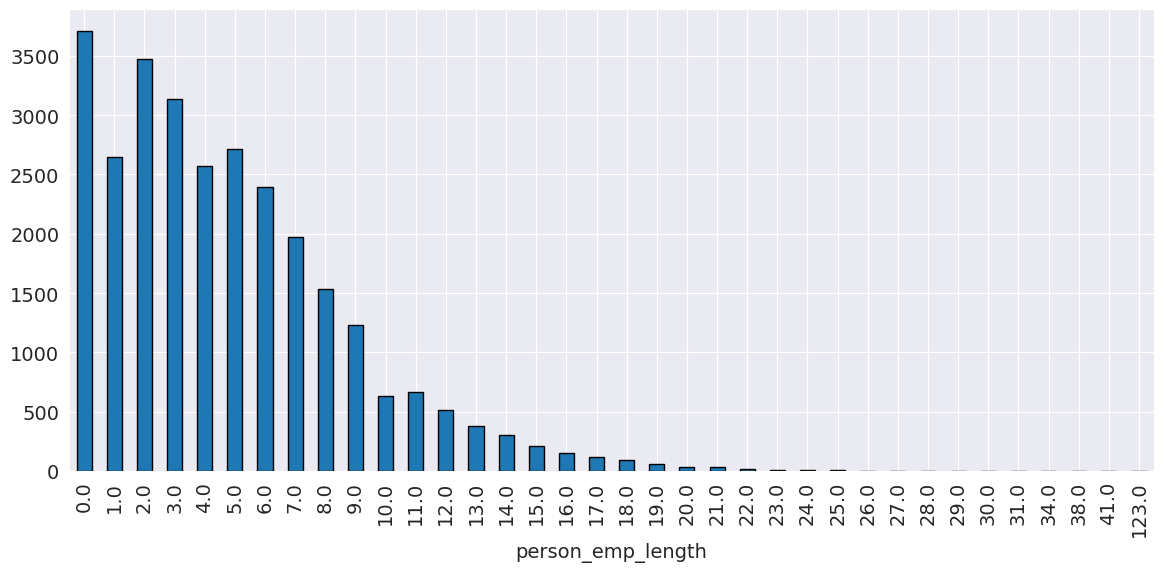

In [146]:
# Explore age distribution. Seem to be 2 extreme values. Seem to be 2 outliers having 123 emp length or ppl having in their twenties
print(data['person_emp_length'].value_counts().reset_index().sort_values(by=['count','person_emp_length'], ascending=[False,False]))
print(data.loc[data['person_emp_length']>94,:])
data['person_emp_length'].value_counts().sort_index().plot.bar(edgecolor='black', figsize=(14,6))

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
81,144,250000,RENT,4.0,VENTURE,C,4800,13.57,0,0.02,N,3
183,144,200000,MORTGAGE,4.0,EDUCATION,B,6000,11.86,0,0.03,N,2
575,123,80004,RENT,2.0,EDUCATION,B,20400,10.25,0,0.25,N,3
747,123,78000,RENT,7.0,VENTURE,B,20000,NaN,0,0.26,N,4
32297,144,6000000,MORTGAGE,12.0,PERSONAL,C,5000,12.73,0,0.00,N,25
32416,94,24000,RENT,1.0,MEDICAL,C,6500,NaN,0,0.27,N,27


#### Prepare Data

In [ ]:
# Drop null values on loan int rate and person emp length

data2 = data.loc[~((data['loan_int_rate'].isnull()) | (data['person_emp_length'].isnull())),:]
struc(data2)


,dtype,notnull,notnull_pct,nunique,sample_1,sample_2,sample_3
person_age,int64,"28,638",100.00%,57,33,36,25
person_income,int64,"28,638",100.00%,3835,140004,37000,61000
person_home_ownership,str,"28,638",100.00%,4,RENT,MORTGAGE,RENT
person_emp_length,float64,"28,638",100.00%,36,7.0,5.0,4.0
loan_intent,str,"28,638",100.00%,6,EDUCATION,MEDICAL,VENTURE
loan_grade,str,"28,638",100.00%,7,D,E,A
loan_amnt,int64,"28,638",100.00%,728,25000,3000,9500
loan_int_rate,float64,"28,638",100.00%,348,15.58,18.39,7.51
loan_status,int64,"28,638",100.00%,2,0,1,0
loan_percent_income,float64,"28,638",100.00%,77,0.18,0.08,0.16


In [153]:
# Drop outliers on age, and emp length
emp_length_over50_II = data2.loc[data2['person_emp_length']>50,:]
age_over_94_II = data2.loc[data2['person_age']>94,:]
data3 = data2.loc[~((data2['person_emp_length']>50) | (data2['person_age']>94)),:]
struc(data3)


,dtype,notnull,notnull_pct,nunique,sample_1,sample_2,sample_3
person_age,int64,"28,632",100.00%,55,22,29,26
person_income,int64,"28,632",100.00%,3834,68004,55400,60000
person_home_ownership,str,"28,632",100.00%,4,RENT,RENT,MORTGAGE
person_emp_length,float64,"28,632",100.00%,35,4.0,2.0,0.0
loan_intent,str,"28,632",100.00%,6,DEBTCONSOLIDATION,HOMEIMPROVEMENT,PERSONAL
loan_grade,str,"28,632",100.00%,7,A,C,A
loan_amnt,int64,"28,632",100.00%,728,9600,7000,9800
loan_int_rate,float64,"28,632",100.00%,348,7.51,10.28,7.75
loan_status,int64,"28,632",100.00%,2,0,0,0
loan_percent_income,float64,"28,632",100.00%,77,0.14,0.13,0.16


In [ ]:
# Write out data
# Write out data
out_data_rpath = os.path.join(Path.cwd().parent,"data/processed/credit_risk_prepared.csv")
print(f'writing {out_data_rpath}')
data3.to_csv(out_data_rpath, index=False)



writing /home/josalkb/Documentos/ml_projects/mlops/credit_risk/credit_risk2605/data/processed/credit_risk_dataset.csv
Finished writing /home/josalkb/Documentos/ml_projects/mlops/credit_risk/credit_risk2605/data/processed/credit_risk_dataset.csv
